In [7]:
!pip install torchinfo
!pip install --quiet torchview graphviz

In [14]:
# Updated imports and constants for melanoma dataset
import math
import os
import time
from datetime import timedelta
import random

import numpy as np
import pandas as pd
from PIL import Image

import matplotlib.pyplot as plt
from IPython.display import SVG, display

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split

from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms, datasets

from torchinfo import summary
from torchview import draw_graph

import torchvision.models as models

# Updated ROOT_DIR for melanoma dataset
ROOT_DIR = '/kaggle/input/datasets/hasnainjaved/melanoma-skin-cancer-dataset-of-10000-images/melanoma_cancer_dataset'
IMG_SIZE = 224
BATCH_SIZE = 6
NUM_WORKERS = 4
RANDOM_STATE = 42

# Updated classes for melanoma dataset
CLASSES = ["benign", "malignant"]


In [15]:
for root, dirs, files in os.walk('/kaggle/input'):
    print(root)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/hasnainjaved
/kaggle/input/datasets/hasnainjaved/melanoma-skin-cancer-dataset-of-10000-images
/kaggle/input/datasets/hasnainjaved/melanoma-skin-cancer-dataset-of-10000-images/melanoma_cancer_dataset
/kaggle/input/datasets/hasnainjaved/melanoma-skin-cancer-dataset-of-10000-images/melanoma_cancer_dataset/test
/kaggle/input/datasets/hasnainjaved/melanoma-skin-cancer-dataset-of-10000-images/melanoma_cancer_dataset/test/benign
/kaggle/input/datasets/hasnainjaved/melanoma-skin-cancer-dataset-of-10000-images/melanoma_cancer_dataset/test/malignant
/kaggle/input/datasets/hasnainjaved/melanoma-skin-cancer-dataset-of-10000-images/melanoma_cancer_dataset/train
/kaggle/input/datasets/hasnainjaved/melanoma-skin-cancer-dataset-of-10000-images/melanoma_cancer_dataset/train/benign
/kaggle/input/datasets/hasnainjaved/melanoma-skin-cancer-dataset-of-10000-images/melanoma_cancer_dataset/train/malignant


In [16]:
ROOT_DIR = '/kaggle/input/datasets/hasnainjaved/melanoma-skin-cancer-dataset-of-10000-images/melanoma_cancer_dataset'

In [17]:
# Define transforms
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

# Load datasets using ImageFolder
train_dir = os.path.join(ROOT_DIR, 'train')
test_dir = os.path.join(ROOT_DIR, 'test')

train_dataset_full = datasets.ImageFolder(root=train_dir, transform=transform)
test_dataset = datasets.ImageFolder(root=test_dir, transform=transform)

print(f"Total training samples: {len(train_dataset_full)}")
print(f"Total test samples: {len(test_dataset)}")
print(f"Training classes: {train_dataset_full.classes}")
print(f"Test classes: {test_dataset.classes}")


Total training samples: 9605
Total test samples: 1000
Training classes: ['benign', 'malignant']
Test classes: ['benign', 'malignant']


In [18]:
# Split training set to create validation set (20% from training folder)
train_indices, val_indices = train_test_split(
    list(range(len(train_dataset_full))), 
    test_size=0.2, 
    stratify=[label for _, label in train_dataset_full.samples],
    random_state=RANDOM_STATE
)

# Create subset datasets
train_dataset = Subset(train_dataset_full, train_indices)
val_dataset = Subset(train_dataset_full, val_indices)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")


Training samples: 7684
Validation samples: 1921


In [19]:
# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print("Data loaders created successfully!")


Data loaders created successfully!


In [25]:
def print_split_stats(train_dataset, val_dataset, test_dataset, classes):
    
    def count_per_class(dataset):
        counts = {}
        
        if hasattr(dataset, 'indices'):  # Subset case
            samples = dataset.dataset.samples
            indices = dataset.indices
            for idx in indices:
                _, label = samples[idx]
                counts[label] = counts.get(label, 0) + 1
        else:  # Normal dataset
            for _, label in dataset.samples:
                counts[label] = counts.get(label, 0) + 1
                
        return counts
    
    # Count samples
    train_counts = count_per_class(train_dataset)
    val_counts = count_per_class(val_dataset)
    test_counts = count_per_class(test_dataset)
    
    all_classes = sorted(set(train_counts) | set(val_counts) | set(test_counts))
    
    print(f"{'Class':<10}{'Train':>10}{'Val':>14}{'Test':>14}{'Total':>14}")
    print("-" * 65)
    
    total_train = sum(train_counts.values())
    total_val = sum(val_counts.values())
    total_test = sum(test_counts.values())
    
    for class_idx in all_classes:
        class_name = classes[class_idx]
        
        train_count = train_counts.get(class_idx, 0)
        val_count = val_counts.get(class_idx, 0)
        test_count = test_counts.get(class_idx, 0)
        class_total = train_count + val_count + test_count
        
        print(f"{class_name:<10}"
              f"{train_count:>10}"
              f"{val_count:>14}"
              f"{test_count:>14}"
              f"{class_total:>14}")
    
    print("-" * 65)
    print(f"{'Total':<10}"
          f"{total_train:>10}"
          f"{total_val:>14}"
          f"{total_test:>14}"
          f"{(total_train + total_val + total_test):>14}")

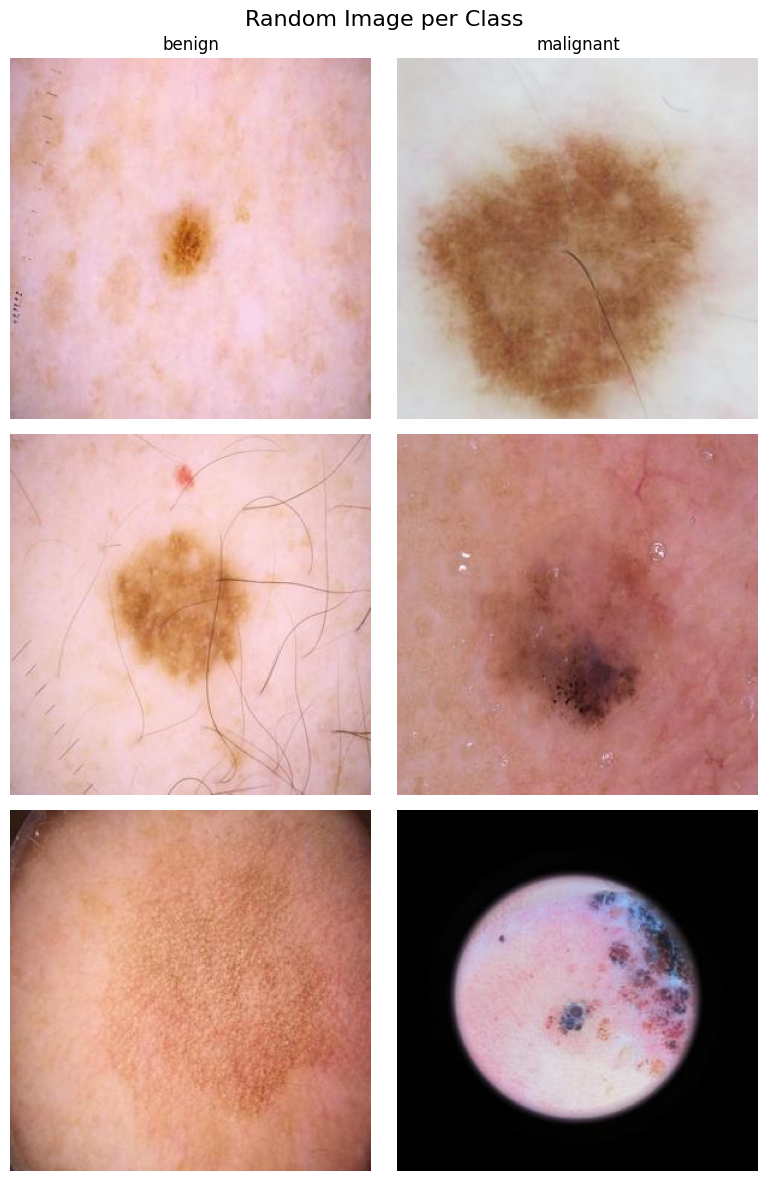

In [26]:
# Function to show random images per class (modified for ImageFolder structure)
def show_random_images_per_class(dataset, classes, title="Random Image per Class", num_samples=3):
    # Group samples by class
    class_samples = {}
    samples = dataset.dataset.samples if hasattr(dataset, 'dataset') else dataset.samples
    
    for img_path, label in samples:
        if label not in class_samples:
            class_samples[label] = []
        class_samples[label].append(img_path)
    
    num_classes = len(classes)
    fig, axs = plt.subplots(num_samples, num_classes, figsize=(4 * num_classes, 4 * num_samples))
    
    if num_classes == 1:
        axs = axs.reshape(-1, 1)
    if num_samples == 1:
        axs = axs.reshape(1, -1)
    
    for class_idx in range(num_classes):
        class_name = classes[class_idx]
        if class_idx in class_samples:
            # Randomly sample images for this class
            selected_images = random.sample(class_samples[class_idx], min(num_samples, len(class_samples[class_idx])))
            
            for sample_idx in range(num_samples):
                if sample_idx < len(selected_images):
                    img_path = selected_images[sample_idx]
                    try:
                        image = Image.open(img_path).convert('RGB')
                        axs[sample_idx, class_idx].imshow(image)
                        if sample_idx == 0:  # Title only on top row
                            axs[sample_idx, class_idx].set_title(class_name, fontsize=12)
                    except Exception as e:
                        axs[sample_idx, class_idx].set_title(f"{class_name}\n(Error)", fontsize=10)
                else:
                    axs[sample_idx, class_idx].set_title(f"{class_name}\n(No Image)", fontsize=10)
                axs[sample_idx, class_idx].axis('off')
        else:
            for sample_idx in range(num_samples):
                axs[sample_idx, class_idx].axis("off")
                axs[sample_idx, class_idx].set_title(f"{class_name}\n(No Data)", fontsize=10)
    
    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

# Show random images
show_random_images_per_class(train_dataset, CLASSES)


In [41]:
def print_split_stats(train_dataset, val_dataset, test_dataset, classes):
    
    def count_per_class(dataset):
        counts = {}
        
        if hasattr(dataset, 'indices'):  # Subset
            samples = dataset.dataset.samples
            for idx in dataset.indices:
                _, label = samples[idx]
                counts[label] = counts.get(label, 0) + 1
        else:  # Normal dataset
            for _, label in dataset.samples:
                counts[label] = counts.get(label, 0) + 1
                
        return counts
    
    # Get counts
    train_counts = count_per_class(train_dataset)
    val_counts = count_per_class(val_dataset)
    test_counts = count_per_class(test_dataset)
    
    all_classes = sorted(set(train_counts) | set(val_counts) | set(test_counts))
    
    print(f"{'Class':<10}{'Train':>15}{'Val':>15}{'Test':>15}{'Total':>15}")
    print("-" * 75)
    
    total_train = sum(train_counts.values())
    total_val = sum(val_counts.values())
    total_test = sum(test_counts.values())
    
    for class_idx in all_classes:
        class_name = classes[class_idx]
        
        train_count = train_counts.get(class_idx, 0)
        val_count = val_counts.get(class_idx, 0)
        test_count = test_counts.get(class_idx, 0)
        class_total = train_count + val_count + test_count
        
        train_pct = (train_count / class_total * 100) if class_total else 0
        val_pct = (val_count / class_total * 100) if class_total else 0
        test_pct = (test_count / class_total * 100) if class_total else 0
        
        print(f"{class_name:<10}"
              f"{train_count:>6} ({train_pct:>5.2f}%)"
              f"{val_count:>8} ({val_pct:>5.2f}%)"
              f"{test_count:>8} ({test_pct:>5.2f}%)"
              f"{class_total:>10}")
    
    print("-" * 75)
    
    overall_total = total_train + total_val + total_test
    
    print(f"{'Total':<10}"
          f"{total_train:>6} ({100 * total_train / overall_total:>5.2f}%)"
          f"{total_val:>8} ({100 * total_val / overall_total:>5.2f}%)"
          f"{total_test:>8} ({100 * total_test / overall_total:>5.2f}%)"
          f"{overall_total:>10}")

In [28]:
# Define number of classes for melanoma classification
num_classes = 2  # benign vs malignant

# Load pretrained EfficientNet-B0 model
model = models.efficientnet_b0(pretrained=True)

# Replace the classification head
in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, num_classes)

# Display model summary
summary(model, input_size=(1, 3, 224, 224),
        col_names=["input_size", "output_size", "num_params", "trainable"])

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print(f"Using device: {device}")


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 180MB/s]


Using device: cuda


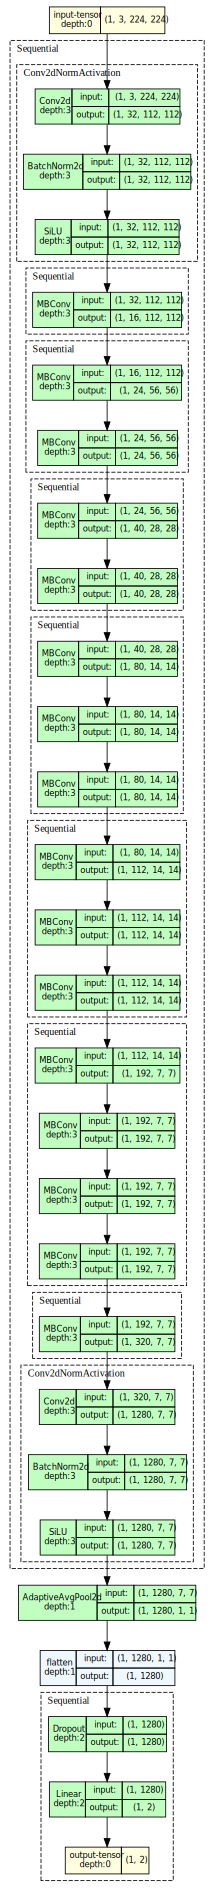

In [29]:
# Dummy input for visualization
dummy_input = torch.randn(1, 3, 224, 224, device=device)

# Generate and display model graph
model_graph = draw_graph(
    model,
    input_data=dummy_input,
    expand_nested=True,
    save_graph=False
)

svg_output = model_graph.visual_graph.pipe(format='svg')
display(SVG(svg_output))


In [30]:
# Custom metrics function (updated for 2-class problem)
def custom_metrics(y_pred, y_true, loss):
    y_pred_classes = torch.argmax(y_pred, dim=1)

    y_true_numpy = y_true.cpu().numpy()
    y_pred_classes_numpy = y_pred_classes.cpu().numpy()
    accuracy = accuracy_score(y_true_numpy, y_pred_classes_numpy)

    precision = precision_score(y_true_numpy, y_pred_classes_numpy, average='weighted', zero_division=0)
    recall = recall_score(y_true_numpy, y_pred_classes_numpy, average='weighted', zero_division=0)
    f1 = f1_score(y_true_numpy, y_pred_classes_numpy, average='weighted', zero_division=0)

    cm = confusion_matrix(y_true_numpy, y_pred_classes_numpy)

    # For binary classification
    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
        specificity = tn / (tn + fp) if (tn + fp) != 0 else 0.0
        sensitivity = tp / (tp + fn) if (tp + fn) != 0 else 0.0
    else:
        # Handle edge cases
        tn = cm[0, 0] if cm.shape[0] > 0 and cm.shape[1] > 0 else 0
        fp = cm[0, 1:].sum() if cm.shape[1] > 1 else 0
        fn = cm[1:, 0].sum() if cm.shape[0] > 1 else 0
        tp = cm[1:, 1:].sum() if cm.shape[0] > 1 and cm.shape[1] > 1 else 0
        specificity = tn / (tn + fp) if (tn + fp) != 0 else 0.0
        sensitivity = tp / (tp + fn) if (tp + fn) != 0 else 0.0

    mcc = matthews_corrcoef(y_true_numpy, y_pred_classes_numpy)

    # Calculate AUC for binary classification
    try:
        # Get probabilities for positive class (malignant)
        y_pred_proba = torch.softmax(y_pred, dim=1)
        y_pred_positive = y_pred_proba[:, 1].cpu().numpy()  # Probability of malignant class
        
        # Calculate AUC
        auc_score = roc_auc_score(y_true_numpy, y_pred_positive)
    except ValueError:
        auc_score = 0.0

    metrics = {
        "loss": loss,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "specificity": specificity,
        "sensitivity": sensitivity,
        "mcc": mcc,
        "auc": auc_score,
    }

    return metrics


In [31]:
# Hyperparameters
num_epochs = 35
initial_lr = 0.0006
decay_start_epoch = 16
decay_factor = 0.96

# Criterion, optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=initial_lr)

# Metrics initialization
metric_names = ["loss", "accuracy", "precision", "recall", "f1_score",
                "specificity", "sensitivity", "mcc", "auc"]
train_metrics_history = {metric: [] for metric in metric_names}
val_metrics_history = {metric: [] for metric in metric_names}

total_training_time = 0.0
total_validation_time = 0.0

print("Training configuration set up successfully!")


Training configuration set up successfully!


In [32]:
# Training and validation loop
for epoch in range(num_epochs):
    start_time = time.time()

    # Training loop
    model.train()
    total_train_loss = 0.0
    all_train_predictions = []
    all_train_targets = []

    for batch_idx, (data, targets) in enumerate(tqdm(train_loader, desc=f"Training Epoch [{epoch + 1}/{num_epochs}]")):
        data = data.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()
        outputs = model(data)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()
        all_train_predictions.extend(outputs.detach().cpu().numpy())
        all_train_targets.extend(targets.detach().cpu().numpy())

    end_time = time.time()
    epoch_training_time = end_time - start_time
    total_training_time += epoch_training_time

    average_train_loss = total_train_loss / len(train_loader)
    all_train_predictions = np.array(all_train_predictions)
    all_train_targets = np.array(all_train_targets)

    train_metrics = custom_metrics(torch.tensor(all_train_predictions), torch.tensor(all_train_targets), average_train_loss)
    training_metrics_line = "Train Metrics - " + ", ".join([f"{k}: {v:.4f}" for k, v in train_metrics.items()])
    print(training_metrics_line)

    for metric in metric_names:
        train_metrics_history[metric].append(train_metrics[metric])

    # Validation loop
    model.eval()
    total_val_loss = 0.0
    all_val_predictions = []
    all_val_targets = []
    start_val_time = time.time()

    with torch.no_grad():
        for batch_idx, (data, targets) in enumerate(tqdm(val_loader, desc="Validating Model")):
            data = data.to(device)
            targets = targets.to(device)

            outputs = model(data)
            loss = criterion(outputs, targets)
            total_val_loss += loss.item()

            all_val_predictions.extend(outputs.detach().cpu().numpy())
            all_val_targets.extend(targets.detach().cpu().numpy())

    end_val_time = time.time()
    epoch_validation_time = end_val_time - start_val_time
    total_validation_time += epoch_validation_time

    average_val_loss = total_val_loss / len(val_loader)
    all_val_predictions = np.array(all_val_predictions)
    all_val_targets = np.array(all_val_targets)

    val_metrics = custom_metrics(torch.tensor(all_val_predictions), torch.tensor(all_val_targets), average_val_loss)
    validation_metrics_line = "Val Metrics - " + ", ".join([f"{k}: {v:.4f}" for k, v in val_metrics.items()])
    print(validation_metrics_line)

    for metric in metric_names:
        val_metrics_history[metric].append(val_metrics[metric])

    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch+1}/{num_epochs} — Loss: {loss.item():.4f} — LR: {current_lr:.6f}")

print(f"Total Training Time: {str(timedelta(seconds=total_training_time))}")
print(f"Total Validation Time: {str(timedelta(seconds=total_validation_time))}")

avg_training_time_per_epoch = total_training_time / (epoch + 1)
avg_validation_time_per_epoch = total_validation_time / (epoch + 1)
print(f"Average Training Time per Epoch: {str(timedelta(seconds=avg_training_time_per_epoch))}")
print(f"Average Validation Time per Epoch: {str(timedelta(seconds=avg_validation_time_per_epoch))}")


Training Epoch [1/35]: 100%|██████████| 1281/1281 [00:52<00:00, 24.25it/s]


Train Metrics - loss: 0.3097, accuracy: 0.8757, precision: 0.8762, recall: 0.8757, f1_score: 0.8755, specificity: 0.9018, sensitivity: 0.8474, mcc: 0.7513, auc: 0.9403


Validating Model: 100%|██████████| 321/321 [00:04<00:00, 65.64it/s]


Val Metrics - loss: 0.2109, accuracy: 0.9209, precision: 0.9209, recall: 0.9209, f1_score: 0.9209, specificity: 0.9220, sensitivity: 0.9197, mcc: 0.8415, auc: 0.9738
Epoch 1/35 — Loss: 0.0019 — LR: 0.000600


Training Epoch [2/35]: 100%|██████████| 1281/1281 [00:52<00:00, 24.25it/s]


...

Val Metrics - loss: 0.3571, accuracy: 0.9297, precision: 0.9306, recall: 0.9297, f1_score: 0.9296, specificity: 0.9560, sensitivity: 0.9012, mcc: 0.8600, auc: 0.9712
Epoch 34/35 — Loss: 0.0002 — LR: 0.000600


Training Epoch [35/35]: 100%|██████████| 1281/1281 [00:53<00:00, 23.81it/s]


Train Metrics - loss: 0.0176, accuracy: 0.9934, precision: 0.9934, recall: 0.9934, f1_score: 0.9934, specificity: 0.9942, sensitivity: 0.9924, mcc: 0.9867, auc: 0.9998


Validating Model: 100%|██████████| 321/321 [00:04<00:00, 66.32it/s]

Val Metrics - loss: 0.3480, accuracy: 0.9209, precision: 0.9224, recall: 0.9209, f1_score: 0.9207, specificity: 0.9550, sensitivity: 0.8838, mcc: 0.8428, auc: 0.9708
Epoch 35/35 — Loss: 0.0001 — LR: 0.000600
Total Training Time: 0:30:58.952607
Total Validation Time: 0:02:44.016035
Average Training Time per Epoch: 0:00:53.112932
Average Validation Time per Epoch: 0:00:04.686172


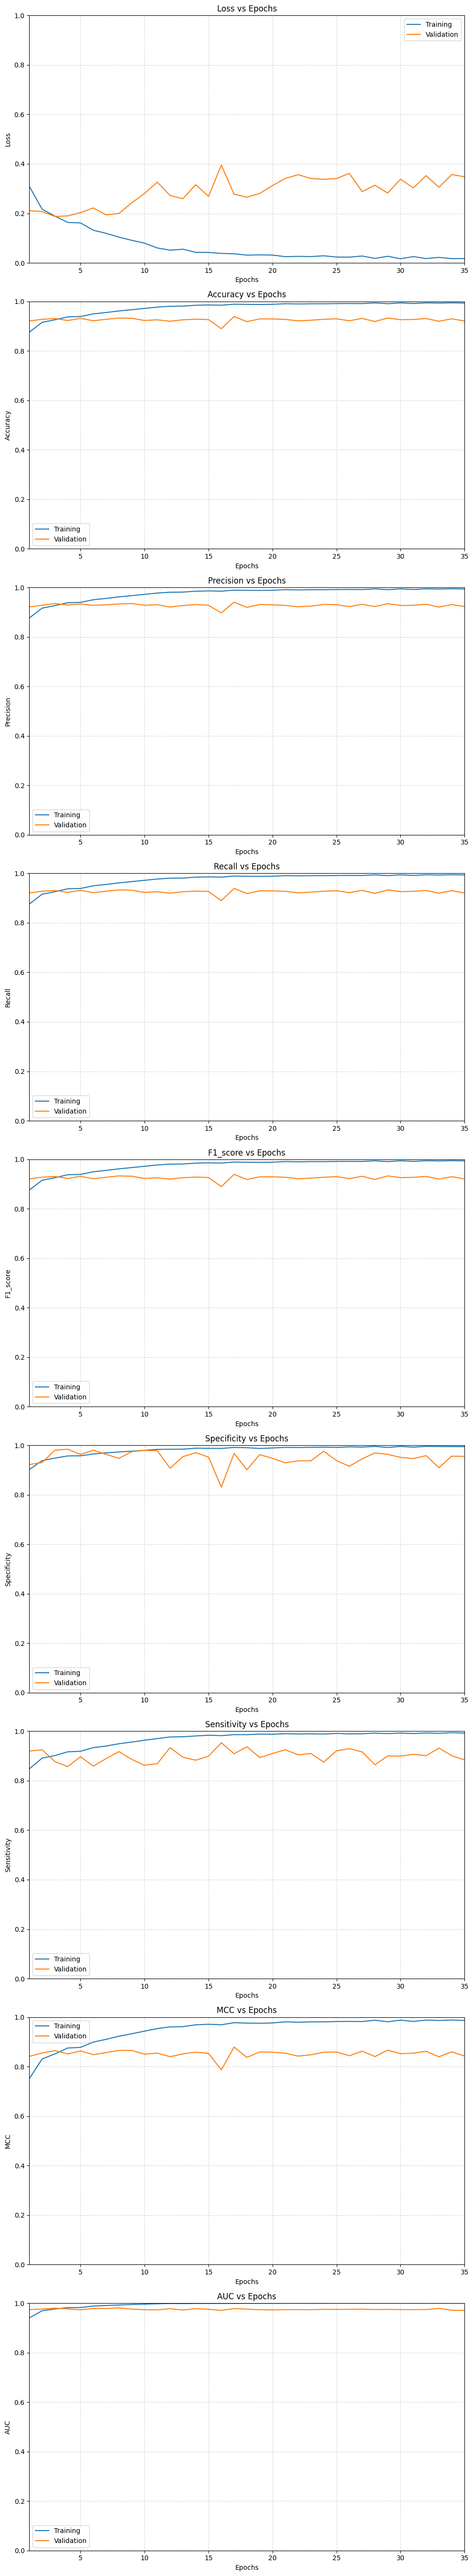

In [33]:
# Plot metrics function
def plot_metrics(train_metrics_history, val_metrics_history, metric_names):
    num_metrics = len(metric_names)
    num_epochs = len(train_metrics_history[metric_names[0]])

    figure, axes = plt.subplots(num_metrics, figsize=(10, 6 * num_metrics)) 
    rng = range(1, num_epochs + 1)

    for ax, metric_name in zip(axes, metric_names):
        train_metric = train_metrics_history[metric_name]
        val_metric = val_metrics_history[metric_name]

        ax.plot(rng, train_metric, label="Training")
        ax.plot(rng, val_metric, label="Validation")
        ax.legend()
        ax.set_xlabel("Epochs")

        if metric_name in ("auc", "mcc"):
            ax.set_ylabel(metric_name.upper())
            ax.set_title(f"{metric_name.upper()} vs Epochs")
        else:
            ax.set_ylabel(metric_name.capitalize())
            ax.set_title(f"{metric_name.capitalize()} vs Epochs")

        max_metric = max(max(train_metric), max(val_metric))
        min_metric = min(min(train_metric), min(val_metric))
        y_max = math.ceil(max_metric)

        if min_metric > 0 or max_metric > 1:
            ax.set_ylim(0, y_max)
        else:
            ax.set_ylim(min_metric, y_max)

        ax.grid(True, linestyle='--', alpha=0.5)
        # Adjust xlim to avoid identical low and high limits.
        if num_epochs == 1:
            ax.set_xlim(0.5, 1.5)
        else:
            ax.set_xlim(1, num_epochs)

    plt.tight_layout()
    plt.show()

# Plot the metrics
plot_metrics(train_metrics_history, val_metrics_history, metric_names)


In [34]:
# Testing loop
model.eval()
total_test_loss = 0.0
all_test_predictions = []
all_test_targets = []

with torch.no_grad():
    for batch_idx, (data, targets) in enumerate(tqdm(test_loader, desc="Testing Model")):
        data = data.to(device)
        targets = targets.to(device)

        outputs = model(data)
        loss = criterion(outputs, targets)
        total_test_loss += loss.item()

        all_test_predictions.extend(outputs.detach().cpu().numpy())
        all_test_targets.extend(targets.detach().cpu().numpy())

all_test_predictions = np.array(all_test_predictions)
all_test_targets = np.array(all_test_targets)

average_test_loss = total_test_loss / len(test_loader)
test_metrics = custom_metrics(torch.tensor(all_test_predictions), torch.tensor(all_test_targets), average_test_loss)
testing_metrics_line = "Test Metrics - " + ", ".join([f"{k}: {v:.4f}" for k, v in test_metrics.items()])
print(testing_metrics_line)


Testing Model: 100%|██████████| 167/167 [00:02<00:00, 62.03it/s]

Test Metrics - loss: 0.4658, accuracy: 0.9200, precision: 0.9246, recall: 0.9200, f1_score: 0.9198, specificity: 0.9720, sensitivity: 0.8680, mcc: 0.8446, auc: 0.9645


In [35]:
# Generate classification report for melanoma dataset
true_labels = np.array(all_test_targets)
predicted_labels = np.argmax(np.array(all_test_predictions), axis=1)

true_labels = true_labels.astype(int)
predicted_labels = predicted_labels.astype(int)

# Generate classification report
report = classification_report(
    true_labels,
    predicted_labels,
    target_names=CLASSES,
    digits=4
)

# Accuracy & error summary
accuracy = accuracy_score(true_labels, predicted_labels)
num_errors = np.sum(true_labels != predicted_labels)

# Display results
print(report)
print(f'There were {num_errors} errors in {len(predicted_labels)} tests for an accuracy of {accuracy * 100:6.2f}%')


              precision    recall  f1-score   support

      benign     0.8804    0.9720    0.9240       500
   malignant     0.9688    0.8680    0.9156       500

    accuracy                         0.9200      1000
   macro avg     0.9246    0.9200    0.9198      1000
weighted avg     0.9246    0.9200    0.9198      1000

There were 80 errors in 1000 tests for an accuracy of  92.00%
